# Exercise 4: Image Filtering

In [1]:
from skimage import color, io, measure, img_as_ubyte
from skimage.measure import profile_line
from skimage.transform import rescale, resize
import matplotlib.pyplot as plt
import numpy as np
import pydicom as dicom

In [2]:
from scipy.ndimage import correlate

In [3]:
input_img = np.arange(25).reshape(5, 5)
print(input_img)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]


In [4]:
weights = [[0, 1, 0],
		   [1, 2, 1],
		   [0, 1, 0]]

In [5]:
res_img = correlate(input_img, weights)
print(res_img)

[[  6  11  17  23  28]
 [ 31  36  42  48  53]
 [ 61  66  72  78  83]
 [ 91  96 102 108 113]
 [116 121 127 133 138]]


## Exercise 1

In [7]:
res_img[3, 3]

np.int64(108)

Here we are using a weighted averaging filter (also cross filter or diamond filter), which smooths/blurs an image while somewhat being more edge-preserving than a uniform blur. Tends to preserve horizontal and vertical features better than diagonal ones.

108 = (12 × 0) + (13 × 1) + (14 × 0) + (17 × 1) + (18 × 2) + (19 × 1) + (22 × 0) + (23 × 1) + (24 × 0)

In [8]:
res_img[0, 1]

np.int64(11)

At the boundary (row -1, col 1), scipy.ndimage.correlate uses mirror mode by default. This reflects row -1 back to row 0, so position [-1, 1] gets the value from [0, 1], which is 1.

Therefore: 0 + (1 × 1) + 0 + 0 + 2 + 2 + 0 + 6 + 0 = 11 

## Exercise 2

In [10]:
res_img_constant = correlate(input_img, weights, mode="constant", cval=10)
print(res_img_constant)

[[ 26  20  25  30  40]
 [ 36  36  42  48  54]
 [ 61  66  72  78  79]
 [ 86  96 102 108 104]
 [ 96 110 115 120 110]]


First and last rows as well as first and last columns differ when using `reflect` vs `constant` mode for the border. Using the `constant` mode with constant value 10 makes the border values to be higher where the reflected value would be <10 and lower when the reflected value would be >10.

## Exercise 3

In [52]:
# Directory containing images
in_dir = "data/"

# Gaussian image
im_name = "Gaussian.png"

# Read the image
im_org = io.imread(in_dir + im_name)

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/2766639421.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/2766639421.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


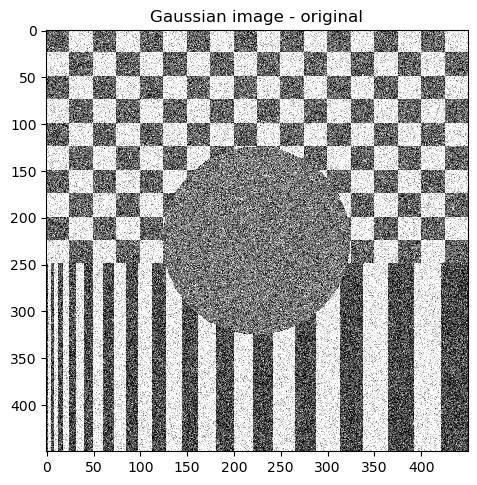

In [53]:
io.imshow(im_org)
plt.title('Gaussian image - original')
io.show()

In [54]:
im_org_grayscale = img_as_ubyte(color.rgb2gray(im_org))

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/2725854095.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org_grayscale)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/2725854095.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


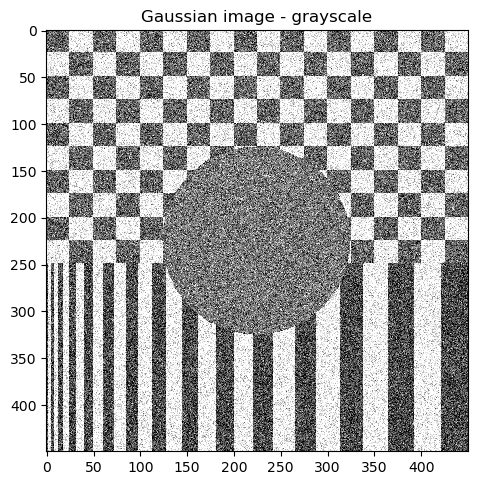

In [55]:
io.imshow(im_org_grayscale)
plt.title('Gaussian image - grayscale')
io.show()

In [56]:
print(im_org.shape)
print(im_org_grayscale.shape)

(450, 450, 3)
(450, 450)


In [ ]:
size = 5

# Two dimensional filter filled with 1
weights = np.ones([size, size])

# Normalize weights
weights = weights / np.sum(weights)

In [19]:
res_img_gaussian = correlate(im_org_grayscale, weights)

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3047735844.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org_grayscale, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3047735844.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(res_img_gaussian, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3047735844.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


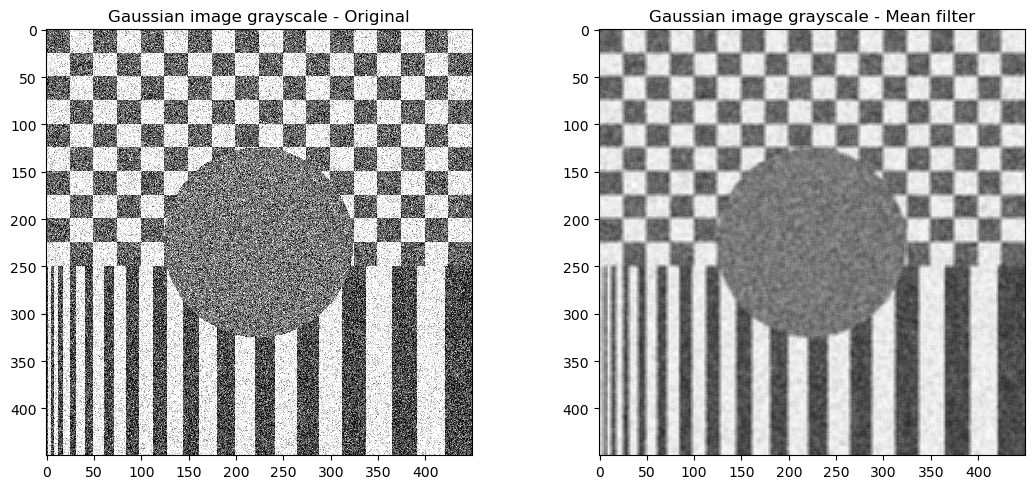

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(im_org_grayscale, ax=ax[0])
ax[0].set_title('Gaussian image grayscale - Original')
io.imshow(res_img_gaussian, ax=ax[1])
ax[1].set_title('Gaussian image grayscale - Mean filter')
fig.show()

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3623585171.py:9: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org_grayscale, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3623585171.py:11: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(res_img_gaussian, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3623585171.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


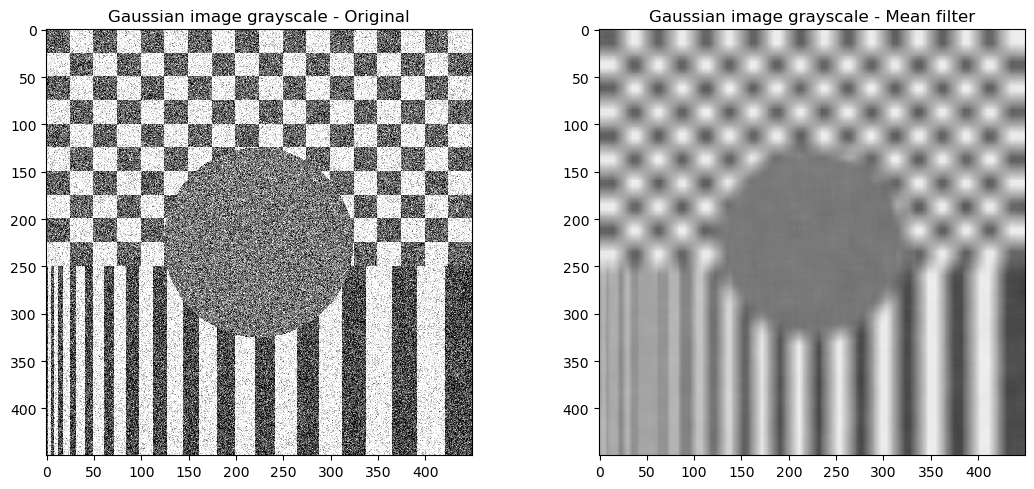

In [23]:
# With different sizes
size = 20
weights = np.ones([size, size])
weights = weights / np.sum(weights)

res_img_gaussian = correlate(im_org_grayscale, weights)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(im_org_grayscale, ax=ax[0])
ax[0].set_title('Gaussian image grayscale - Original')
io.imshow(res_img_gaussian, ax=ax[1])
ax[1].set_title('Gaussian image grayscale - Mean filter')
fig.show()

As we increase the size of the kernel (filter), the image becomes more and more blurred because we are averaging over more pixel values (neighbours area increases).

The blurring smoothes the noise (grain is not so visible) but it also softens the transitions from light to dark areas, making the edges less prominent.

## Exercise 4

In [24]:
from skimage.filters import median

In [30]:
size = 20
footprint = np.ones([size, size])
med_img = median(im_org_grayscale, footprint)

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/2514305863.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org_grayscale, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/2514305863.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(med_img, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/2514305863.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


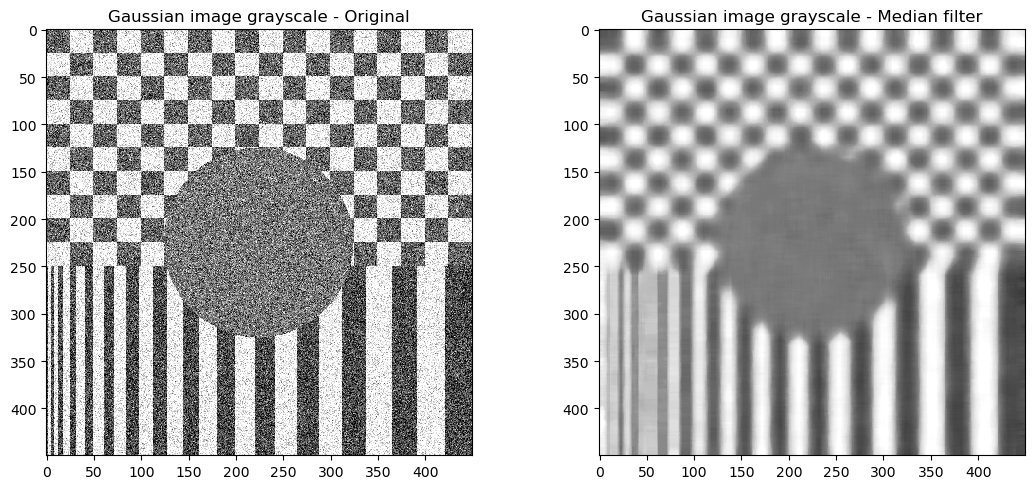

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(im_org_grayscale, ax=ax[0])
ax[0].set_title('Gaussian image grayscale - Original')
io.imshow(med_img, ax=ax[1])
ax[1].set_title('Gaussian image grayscale - Median filter')
fig.show()

A median filter replaces each pixel by the median of neighboring pixels, so it is very good at removing outliers (impulsive noise such as salt-and-pepper) and also reduces Gaussian-like noise to some degree. It also preserves edges better than mean filtering. 

As filter size grows, noise is reduced more, but light-dark transitions become increasingly broadened (less sharp) and fine details are lost.

## Exercise 5

In [42]:
img_salt_pepper = io.imread(in_dir + 'SaltPepper.png')
img_salt_pepper_gray = img_as_ubyte(color.rgb2gray(img_salt_pepper))

In [49]:
size = 20

# Mean filter
weights_mean = np.ones([size, size])
weights_mean = weights_mean / np.sum(weights_mean)

# Median filter
footprint = np.ones([size, size])

In [50]:
res_salt_pepper_mean = correlate(img_salt_pepper_gray, weights_mean)
res_salt_pepper_median = med_img = median(img_salt_pepper_gray, footprint)

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/1120356634.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(res_salt_pepper_mean, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/1120356634.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(res_salt_pepper_median, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/1120356634.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


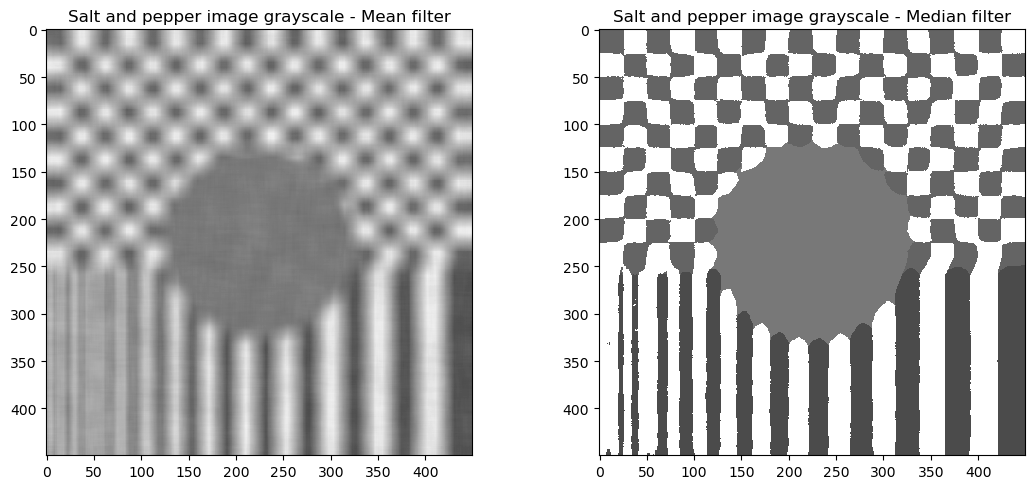

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(res_salt_pepper_mean, ax=ax[0])
ax[0].set_title('Salt and pepper image grayscale - Mean filter')
io.imshow(res_salt_pepper_median, ax=ax[1])
ax[1].set_title('Salt and pepper image grayscale - Median filter')
fig.show()

The mean filter reduces the salt-and-pepper noise only partially, because extreme black/white pixels are averaged with neighbors instead of being removed. This causes visible blur, lowers contrast, and makes edges and fine texture look blurred.

The median filter removes salt-and-pepper noise much better, since isolated outlier pixels are rejected by the median operation. Edges are generally preserved better than with the mean filter, but with larger filter sizes the image starts to look blocky/segmented/staircased, small details disappear, and thin structures can be lost.

As filter size increases:

* Noise suppression improves for both filters.
* Mean filter gives increasing blur and smoother light-dark transitions.
* Median filter keeps transitions sharper at first, but very large windows over-simplify the image and remove detail.

## Exercise 6

In [57]:
from skimage.filters import gaussian

In [62]:
sigma = 3
gauss_img = gaussian(im_org_grayscale, sigma)

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3285358910.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(gauss_img)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3285358910.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


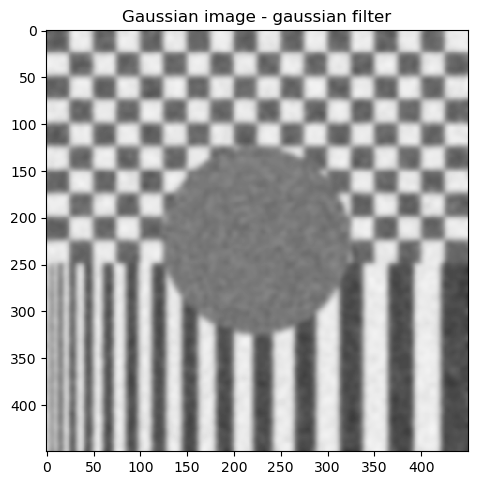

In [63]:
io.imshow(gauss_img)
plt.title('Gaussian image - gaussian filter')
io.show()

When you increase sigma in a Gaussian filter:

-  Wider blur: The Gaussian curve becomes broader, so more distant pixels contribute to the average, creating a stronger smoothing effect.
More detail loss: Finer details, textures, and small structures blur away.
- Better noise reduction: Gaussian noise is smoothed out more effectively.
- Softer edges: Light-dark transitions become increasingly gradual and less sharp.

Essentially, higher sigma = more aggressive blurring. It's similar to increasing filter size, but smoother and more gradual (whereas a median or mean filter with larger kernels can look blockier).

## Exercise 7

In [65]:
img_car = io.imread(in_dir + 'car.png')
img_car_gray = img_as_ubyte(color.rgb2gray(img_car))

In [67]:
size = 20
footprint = np.ones([size, size])
med_img_car = median(img_car_gray, footprint)

In [89]:
sigma = 3
gauss_img_car = gaussian(img_car_gray, sigma)

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3217781438.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(med_img_car, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3217781438.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(gauss_img_car, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3217781438.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


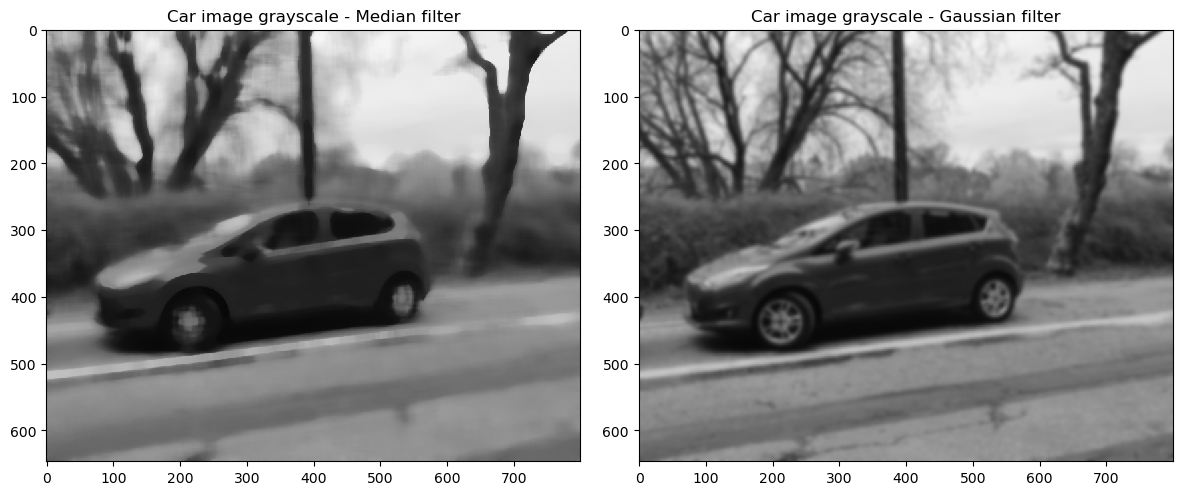

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(med_img_car, ax=ax[0])
ax[0].set_title('Car image grayscale - Median filter')
io.imshow(gauss_img_car, ax=ax[1])
ax[1].set_title('Car image grayscale - Gaussian filter')
fig.show()

The Gaussian creates a smooth gradient across the transition, while the median preserves a more defined edge: the shift from light to dark happens over a narrower region. However, the median can create artifact patterns (blockiness) in smooth areas.

## Exercise 8

In [75]:
from skimage.filters import prewitt_h
from skimage.filters import prewitt_v
from skimage.filters import prewitt

In [78]:
from skimage.color import rgb2gray

In [79]:
img_donald = io.imread(in_dir + 'donald_1.png')
img_donald_gray = rgb2gray(img_donald)

In [80]:
img_donald_prewitt_h = prewitt_h(img_donald_gray)
img_donald_prewitt_v = prewitt_v(img_donald_gray)

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/780563030.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_donald, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/780563030.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_donald_prewitt_h, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/780563030.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_donald_prewitt_v, ax=ax[2])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/780563030.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


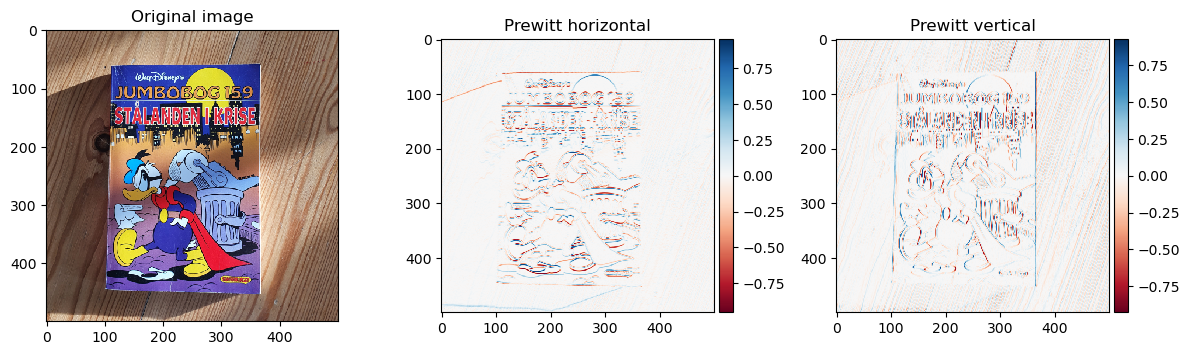

In [81]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
io.imshow(img_donald, ax=ax[0])
ax[0].set_title('Original image')
io.imshow(img_donald_prewitt_h, ax=ax[1])
ax[1].set_title('Prewitt horizontal')
io.imshow(img_donald_prewitt_v, ax=ax[2])
ax[2].set_title('Prewitt vertical')
fig.show()

## Exercise 9

In [82]:
img_donald_prewitt = prewitt(img_donald_gray)

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3455055615.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_donald, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3455055615.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_donald_prewitt, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/3455055615.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


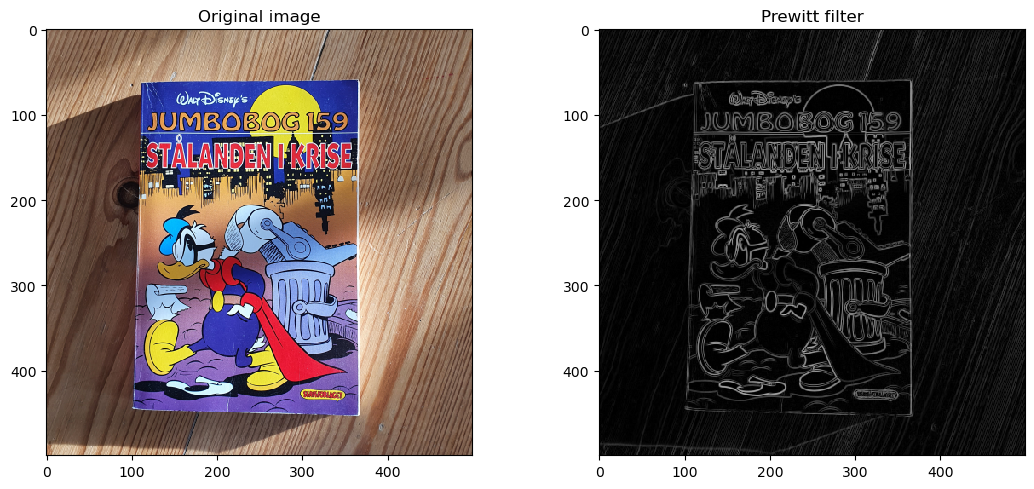

In [85]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(img_donald, ax=ax[0])
ax[0].set_title('Original image')
io.imshow(img_donald_prewitt, ax=ax[1])
ax[1].set_title('Prewitt filter')
fig.show()

## Exercise 10

In [102]:
from skimage.filters import threshold_otsu

In [130]:
# Read the CT image
img_ct_scan = io.imread(in_dir + 'ElbowCTSlice.png')
img_ct_scan_gray = rgb2gray(img_ct_scan)

In [156]:
# Filter the image

# Median filter
size = 15
footprint = np.ones([size, size])
res_img_ct_scan = median(img_ct_scan_gray, footprint)

# Gaussian filter
# sigma = 3
# res_img_ct_scan = gaussian(img_ct_scan_gray, sigma)

In [157]:
# Compute the gradients in the filtered image using Prewitt filter
img_ct_scan_prewitt = prewitt(res_img_ct_scan)

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/146488644.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_ct_scan_prewitt)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/146488644.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


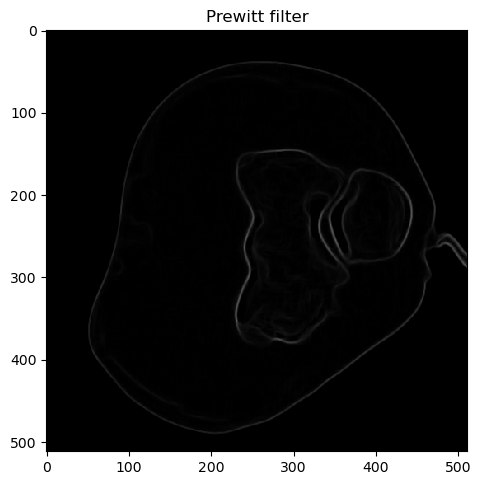

In [158]:
io.imshow(img_ct_scan_prewitt)
plt.title('Prewitt filter')
io.show()

In [159]:
thres = threshold_otsu(img_ct_scan_prewitt)
binary = img_ct_scan_prewitt > thres

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/190651706.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(binary)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_51976/190651706.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


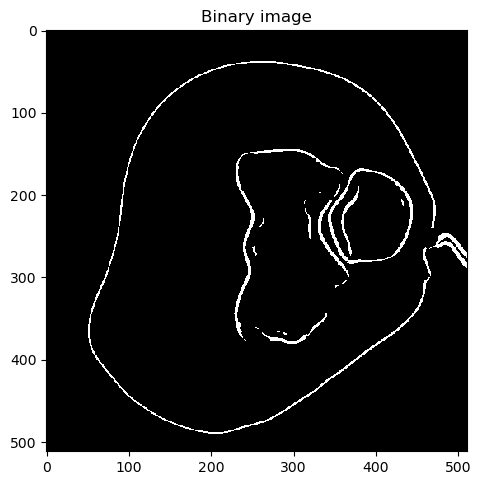

In [160]:
io.imshow(binary)
plt.title('Binary image')
io.show()

For this CT edge-detection task, Gaussian smoothing usually gives the best overall result before Prewitt + Otsu, because it reduces random noise while keeping clinically relevant boundaries relatively continuous. A median filter can help if there are strong outlier pixels, but it may create blocky regions and can weaken thin bone edges when the window is large.

Using both can work, but only lightly: if needed, use a small median first to remove outliers, then a small Gaussian to smooth residual noise. In practice, too much filtering hurts edge detection by reducing gradient strength.

## Exercise 11

In [161]:
def process_gray_image(img, prewitt_flag, otsu_flag):
    """
    Do a simple processing of an input gray scale image and return the processed image.
    # https://scikit-image.org/docs/stable/user_guide/data_types.html#image-processing-pipeline
    """
    # Do something here:
    proc_img = img.copy()
    proc_img_gray = img_as_ubyte(proc_img)
    if prewitt_flag:
        return prewitt(proc_img_gray)
    if otsu_flag:
        return threshold_otsu(proc_img_gray)
    return proc_img_gray

In [162]:
# Automatic edge-detection using Prewitt filter + Otsu thresholding:
proc_img = process_gray_image(img_ct_scan_gray, prewitt_flag=True, otsu_flag=True)

## Exercise 12

In [163]:
def process_gray_image(img, prewitt_flag=False, otsu_flag=False, median_flag=False):
    """
    Do a simple processing of an input gray scale image and return the processed image.
    # https://scikit-image.org/docs/stable/user_guide/data_types.html#image-processing-pipeline
    """
    # Do something here:
    proc_img = img.copy()
    proc_img_gray = img_as_ubyte(proc_img)
    if prewitt_flag:
        return prewitt(proc_img_gray)
    if otsu_flag:
        return threshold_otsu(proc_img_gray)
    if median_flag:
        footprint = np.ones([10, 10])
        proc_img = median(proc_img, footprint)
    return proc_img_gray

In [165]:
# Median filter with size 10x10 kernel
proc_img = process_gray_image(img_ct_scan_gray, median_flag=True)

The median filter is computationally expensive because it has to find the median value in a large neighborhood for every pixel, so the processing becomes slow. As a result, the video pipeline cannot keep up in real time, and the FPS stops rising.